In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import wandb
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import FormatStrFormatter
from soph.utils.config_generator import flatten

/home/shikai_q/miniconda3/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def get_runs(project, filters=None, samples=500):
    """Fetch runs from wandb and return a DataFrame with history and varying config columns."""
    api = wandb.Api()
    runs = api.runs(project, filters=filters or {}, order="-created_at")
    rows = []
    for run in runs:
        config = flatten({k: v for k, v in run.config.items() if not k.startswith("_")})
        hist = pd.DataFrame(run.history(samples=samples))
        rows.append({**config, 'history': hist})
    df = pd.DataFrame(rows)
    fixed_cols = [c for c in df.columns if c != 'history' and df[c].apply(str).nunique() <= 1]
    df = df.drop(columns=fixed_cols)
    return df

In [4]:
filters = {
    "state": {"$in": ["finished", "running"]},
    "config.tag": 'ca_hidden',
    "config.requential": True,
    "config.max_kl": 0.03,
    "config.meta.width": 32,
    "config.meta.steps": 4,
    "config.meta.rule": 30,
    "config.T": 20000,
}
runs = get_runs("shikai/requential", filters)
print(f'{len(runs)} runs loaded')

6 runs loaded


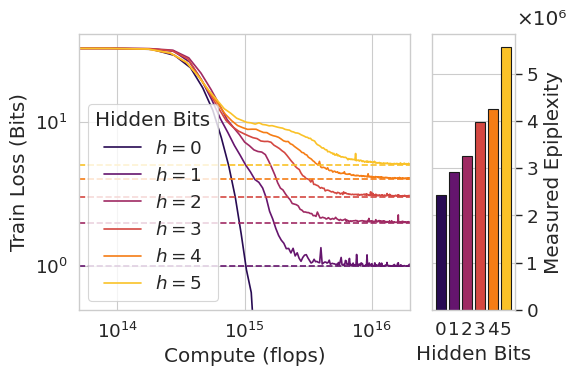

In [5]:
sns.set(style='whitegrid')
sns.set_context("paper", font_scale=1.5)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 4),
                               gridspec_kw={'width_ratios': [8, 2]})

try:
    key = 'kwargs/nbits'
    runs[key]
except KeyError:
    key = 'meta/nbits'
unique_nbits = np.sort(np.unique(runs[key]))
colors = sns.color_palette("inferno", n_colors=len(unique_nbits))
for i, n in enumerate(unique_nbits):
    h = runs[runs[key] == n]['history'].iloc[0]
    ax1.plot(h['compute'], 32 * h['student_loss'] / np.log(2),
             color=colors[i], label=rf'$h={int(n)}$')
    if n:
        ax1.axhline(n, color=colors[i], linestyle='--')
ax1.set(xscale='log', yscale='log',
        xlabel='Compute (flops)', ylabel='Train Loss (Bits)')
ax1.legend(title='Hidden Bits')
ax1.set_xlim(5e13, 2e16)
ax1.set_ylim(0.5, 40)

ends = []
for n in unique_nbits:
    areas = []
    for hist in runs[runs[key] == n]['history']:
        areas.append(hist['K_req'].iloc[-1])
    ends.append(np.vstack(areas).mean(axis=0)[-1] / 1e6)

ax2.bar([int(n) for n in unique_nbits], ends, color=colors, edgecolor='k')
ax2.set(xlabel='Hidden Bits')
ax2.yaxis.set_label_position('right')
ax2.yaxis.tick_right()
ax2.set_ylabel('Measured Epiplexity')
ax2.xaxis.grid(False)
ax2.yaxis.grid(True)
ax2.set_xticks([int(n) for n in unique_nbits])
ax2.set_xticklabels([str(int(n)) for n in unique_nbits])
ax2.text(1.02, 1.02, '\u00d710\u2076', transform=ax2.transAxes,
         va='bottom', ha='left')

plt.tight_layout()
plt.show()